In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re
from datetime import datetime

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


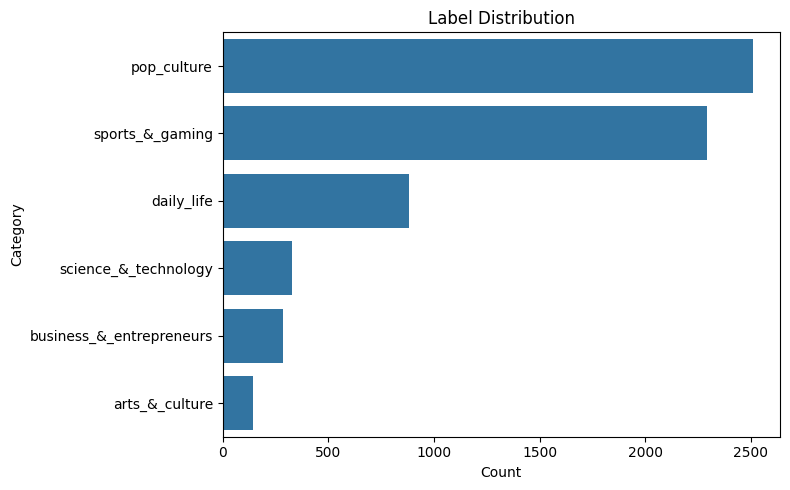

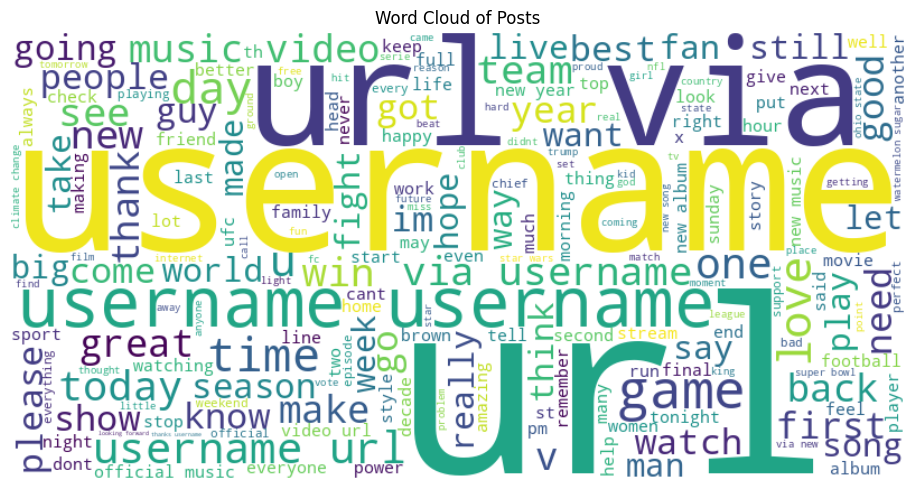

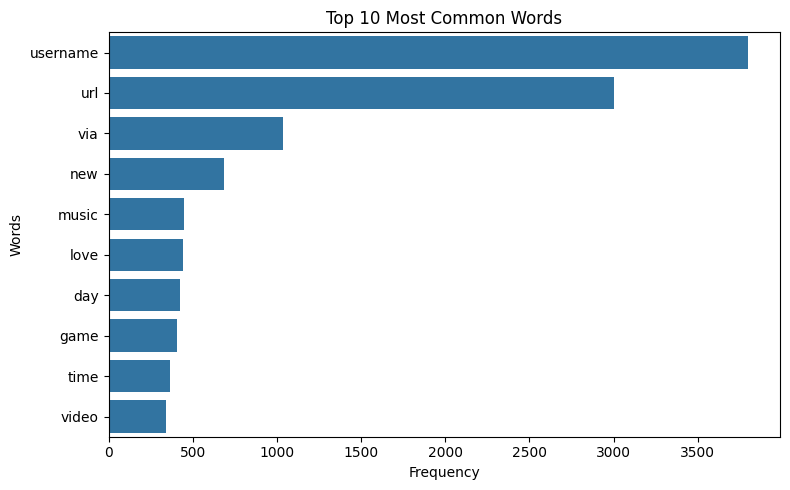

In [3]:
# Load your JSON file
with open('/content/CETM47_24_5-AS2-Data.json', 'r') as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(8, 5))
sns.countplot(y='label_name', data=df, order=df['label_name'].value_counts().index)
plt.title('Label Distribution')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

def clean_text(text):
    text = re.sub(r'@\w+|#\w+|http\S+', '', text)  # Remove mentions, hashtags, links
    text = re.sub(r'[^a-zA-Z\s]', '', text)        # Remove special characters
    text = text.lower()
    return ' '.join([word for word in text.split() if word not in stop_words])

all_text = ' '.join(df['text'].apply(clean_text))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Posts')
plt.tight_layout()
plt.show()

words = all_text.split()
word_freq = Counter(words)
common_words = word_freq.most_common(10)

words, counts = zip(*common_words)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 10 Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

